In [259]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
#pip install xlrd>= 2.0.1

In [260]:
#df = pd.read_excel("../Data/Global Superstore.xls")
df = pd.read_excel("Global Superstore.xls")

In [261]:
df.head(5)
df.tail(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
51285,29002,IN-2014-62366,2014-06-19,2014-06-19,Same Day,KE-16420,Katrina Edelman,Corporate,Kure,Hiroshima,...,OFF-FA-10000746,Office Supplies,Fasteners,"Advantus Thumb Tacks, 12 Pack",65.100,5,0.0,4.5000,0.010,Medium
51286,35398,US-2014-102288,2014-06-20,2014-06-24,Standard Class,ZC-21910,Zuschuss Carroll,Consumer,Houston,Texas,...,OFF-AP-10002906,Office Supplies,Appliances,Hoover Replacement Belt for Commercial Guardsm...,0.444,1,0.8,-1.1100,0.010,Medium
51287,40470,US-2013-155768,2013-12-02,2013-12-02,Same Day,LB-16795,Laurel Beltran,Home Office,Oxnard,California,...,OFF-EN-10001219,Office Supplies,Envelopes,"#10- 4 1/8"" x 9 1/2"" Security-Tint Envelopes",22.920,3,0.0,11.2308,0.010,High
51288,9596,MX-2012-140767,2012-02-18,2012-02-22,Standard Class,RB-19795,Ross Baird,Home Office,Valinhos,São Paulo,...,OFF-BI-10000806,Office Supplies,Binders,"Acco Index Tab, Economy",13.440,2,0.0,2.4000,0.003,Medium
51289,6147,MX-2012-134460,2012-05-22,2012-05-26,Second Class,MC-18100,Mick Crebagga,Consumer,Tipitapa,Managua,...,OFF-PA-10004155,Office Supplies,Paper,"Eaton Computer Printout Paper, 8.5 x 11",61.380,3,0.0,1.8000,0.002,High


# First Inspection

In [262]:
df.shape

(51290, 24)

In [263]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [264]:
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [265]:

df.duplicated().sum()
#there are no duplicates

np.int64(0)

In [266]:
df.nunique()

Row ID            51290
Order ID          25035
Order Date         1430
Ship Date          1464
Ship Mode             4
Customer ID        1590
Customer Name       795
Segment               3
City               3636
State              1094
Country             147
Postal Code         631
Market                7
Region               13
Product ID        10292
Category              3
Sub-Category         17
Product Name       3788
Sales             27200
Quantity             14
Discount             29
Profit            28234
Shipping Cost     17095
Order Priority        4
dtype: int64

In [267]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290,51290,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
min,1.00000,2011-01-01 00:00:00,2011-01-03 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.25000,2012-06-19 00:00:00,2012-06-23 00:00:00,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,2013-07-08 00:00:00,2013-07-12 00:00:00,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,2014-05-22 00:00:00,2014-05-26 00:00:00,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,2014-12-31 00:00:00,2015-01-07 00:00:00,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000
std,14806.29199,NaN,NaN,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810


# Data Cleaning


In [268]:
#columns standardization
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ","_")
df.columns

Index(['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode',
       'customer_id', 'customer_name', 'segment', 'city', 'state', 'country',
       'postal_code', 'market', 'region', 'product_id', 'category',
       'sub-category', 'product_name', 'sales', 'quantity', 'discount',
       'profit', 'shipping_cost', 'order_priority'],
      dtype='object')

In [273]:
#to drop unneccesary columns for eaier aanalysis
df = df.drop(columns = ['row_id', 'order_id','customer_id','customer_name','product_id','postal_code'])

In [274]:
df.head()

,order_date,ship_date,ship_mode,segment,city,state,country,market,region,category,sub-category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority
0,2012-07-31,2012-07-31,Same Day,Consumer,New York City,New York,United States,US,East,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,2013-02-05,2013-02-07,Second Class,Corporate,Wollongong,New South Wales,Australia,APAC,Oceania,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,2013-10-17,2013-10-18,First Class,Consumer,Brisbane,Queensland,Australia,APAC,Oceania,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,2013-01-28,2013-01-30,First Class,Home Office,Berlin,Berlin,Germany,EU,Central,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,2013-11-05,2013-11-06,Same Day,Consumer,Dakar,Dakar,Senegal,Africa,Africa,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


# EDA AND VISUALIZATIONS

### 1. Sales over the years(trends + anomalies + seasonality)
### (line chart)(time series plot)

In [271]:
#sales_trend = df.groupby("order_date")["sales"].sum() # this wont give specifics
sales_trend = df.set_index("order_date").resample("M")["sales"].sum()


C:\Users\HP\AppData\Local\Temp\ipykernel_4740\2819555698.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sales_trend = df.set_index("order_date").resample("M")["sales"].sum()


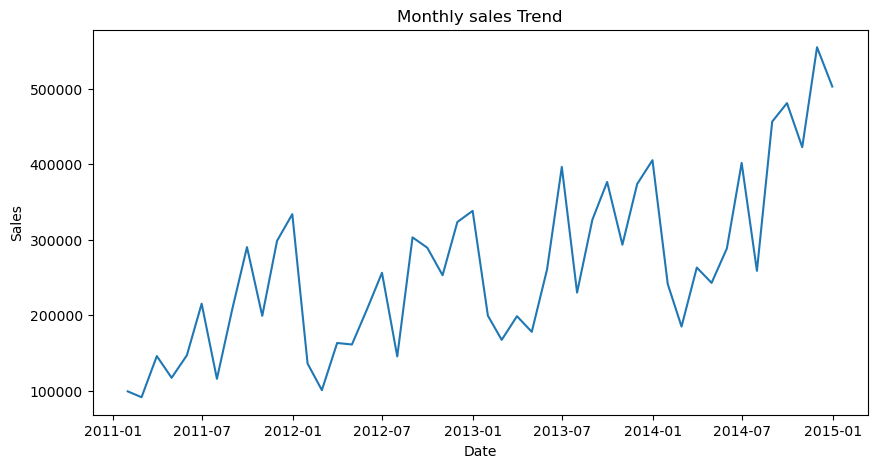

In [272]:
plt.figure(figsize=(10,5))
plt.plot(sales_trend)
plt.title("Monthly sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.savefig('../images/Monthly sales Trend.png', dpi=300, bbox_inches="tight")
plt.show()

In [278]:

# Sales show a clear upward trend over the year, with noticeable spikes in the first and seventh month of the year. 
# This suggests seasonal demand, likely driven by end-of-year purchasing behavior. The business should align inventory and 
# marketing efforts to capitalize on this peak period.


### 2. Profits over the years(trends + anomalies + seasonality)
### (line chart)(time series plot)

In [194]:
profit_trend = df.set_index("order_date").resample("M")["profit"].sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_4740\2987369167.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  profit_trend = df.set_index("order_date").resample("M")["profit"].sum()


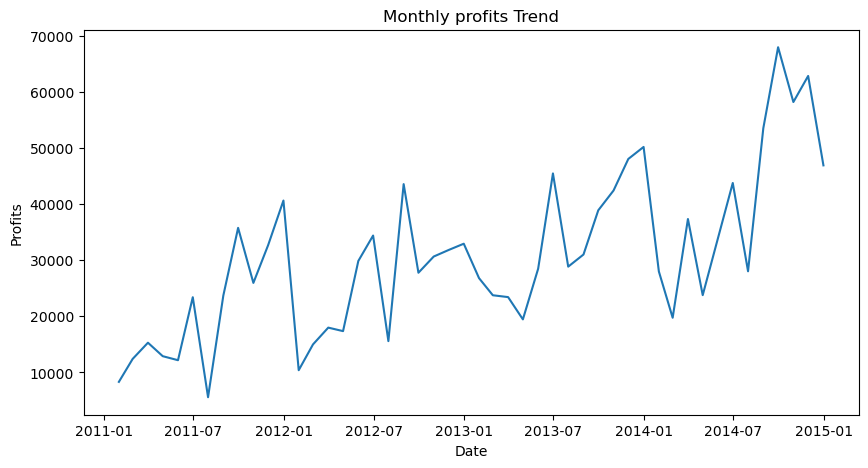

In [195]:
plt.figure(figsize=(10,5))
plt.plot(profit_trend)
plt.title("Monthly profits Trend")
plt.xlabel("Date")
plt.ylabel("Profits")
plt.savefig('../images/Monthly sales Trend.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Profits plot show a clear upward trend over the year, with noticeable spikes in the first and seventh month of the year. 
# This suggests seasonal demand, likely driven by end-of-year purchasing behavior. The business should align inventory and 
# marketing efforts to capitalize on this peak period.


### 3. How does discount distribution vary across ship modes
### Boxplot(shows distribution,reveals median discount,spread,outliers) and Bar chart (mean discount)

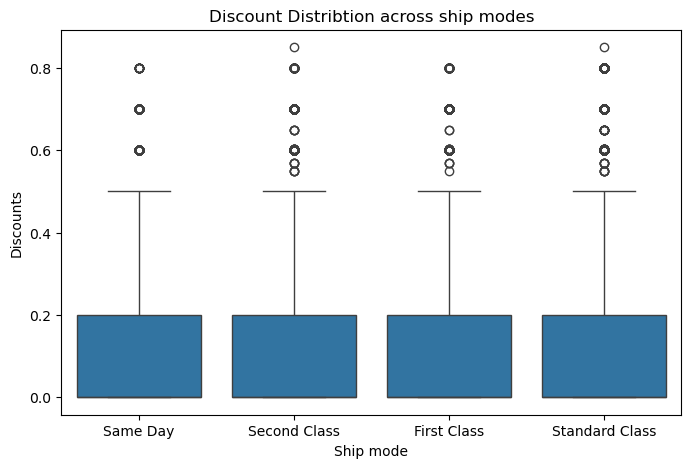

In [196]:
plt.figure(figsize=(8,5))
sns.boxplot(x="ship_mode",y="discount",data = df)
plt.title("Discount Distribtion across ship modes")
plt.xlabel("Ship mode")
plt.ylabel("Discounts")
plt.savefig('../images/Discount Distribtion across ship modes.png', dpi=300, bbox_inches="tight")
plt.show()

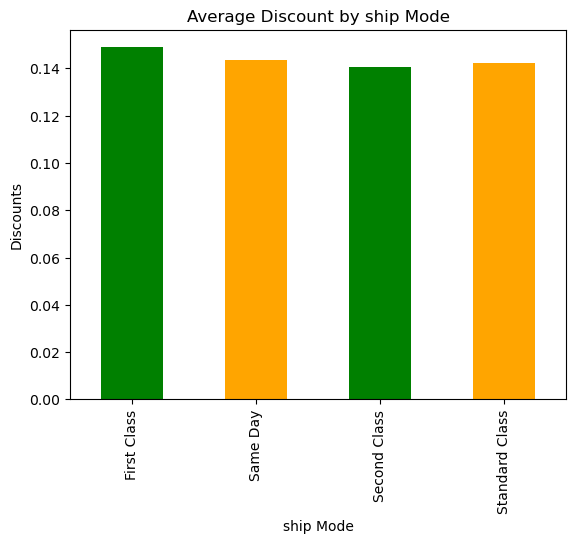

In [282]:
discount_mean = df.groupby("ship_mode")["discount"].mean()
discount_mean.plot(kind = "bar" , color = ["green","orange"])
plt.title("Average Discount by ship Mode")
plt.xlabel("ship Mode")
plt.ylabel("Discounts")
plt.savefig('../images/Average Discount by ship Mode.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Discount distributions are largely similar across ship modes, with significant overlap in median and interquartile ranges. 
# However, Same Day shipping shows slightly higher variability with more extreme discount outliers. This suggests that 
# while shipping speed does not strongly determine discount strategy, urgent orders may occasionally receive aggressive pricing adjustments.

### 4. Is there an association between ship mode and order priority
### Bar chart (compare 2 categorical variables),preferably grouped bar chart(starked chat)

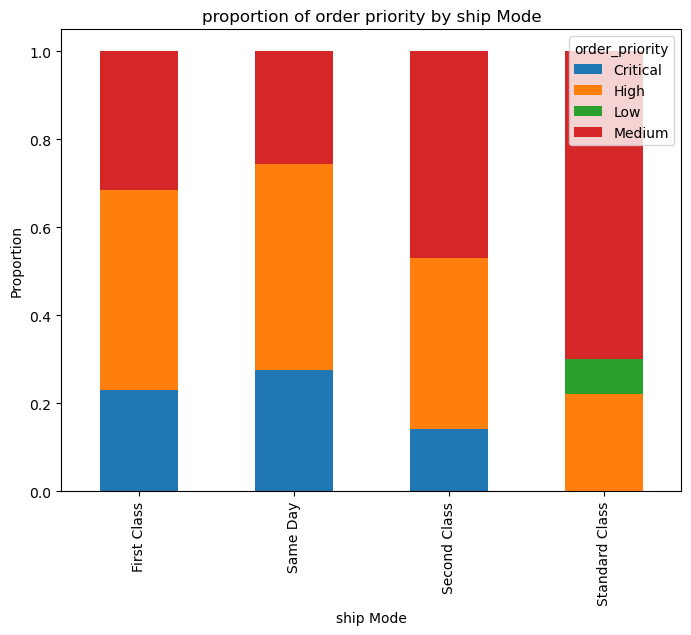

In [198]:
#create a cross tab
cross_tab = pd.crosstab(df["ship_mode"],df["order_priority"])
#To normalize
cross_tab = cross_tab.div(cross_tab.sum(axis=1) , axis=0)
#plot
cross_tab.plot(kind="bar", stacked=True, figsize=(8,6))
plt.title("proportion of order priority by ship Mode")
plt.xlabel("ship Mode")
plt.ylabel("Proportion")
plt.savefig('../images/proportion of order priority by ship Mode.png', dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Same Day shipping is disproportionately associated with critical priority orders, while Standard Class 
# is dominated by medium and low priorities. This indicates a clear alignment between urgency and shipping speed, 
# suggesting operational prioritization of critical orders through faster delivery channels.

### 4. Which segments generated more sales and profits
### Bar chart(categorical data vs numerical data)

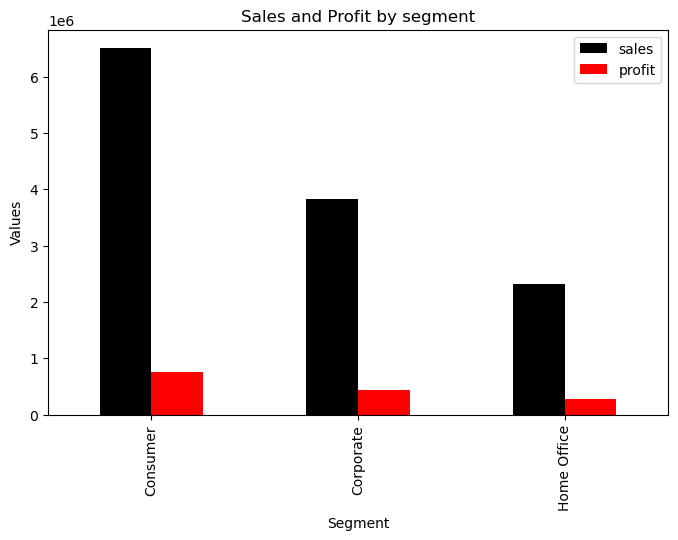

In [221]:
seg_perf = df.groupby("segment")[["sales","profit"]].sum()

seg_perf.plot(kind="bar",figsize=(8,5) , color=["black","red"])
plt.title("Sales and Profit by segment")
plt.xlabel("Segment")
plt.ylabel("Values")
plt.savefig('../images/Sales and Profit by segment.png', dpi=300, bbox_inches="tight")
plt.show()

In [283]:
# The Consumer segment generates the highest sales and also leads in profitability, 
# indicating strong revenue efficiency and high-margin products. 
# In contrast, corperate shows relatively high sales but significantly lower profit,
# suggesting margin compression likely due to higher costs or discounting. This indicates that while corporate contributes to revenue, 
# it may not be as financially efficient, and cost or pricing strategies should be reviewed.

### 4. Which country are top contributors to sales and profit
### Horizontal Bar chart(categorical data vs numerical data)

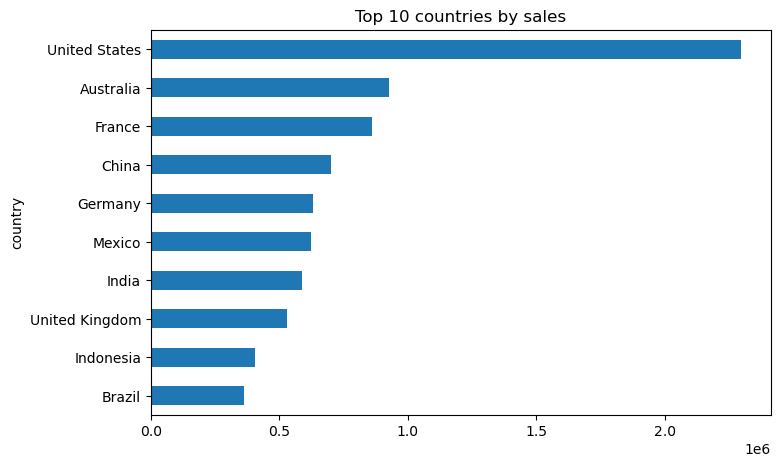

In [222]:
#aggregate
country_perf = df.groupby("country")[["sales","profit"]].sum()

#get top countries by sale
top_country_sales = country_perf.sort_values(by="sales",ascending = False).head(10)
top_country_sales["sales"].sort_values().plot(kind="barh" , figsize=(8,5))
plt.title("Top 10 countries by sales")
plt.savefig('../images/Top 10 countries by sales.png', dpi=300, bbox_inches="tight")
plt.show()

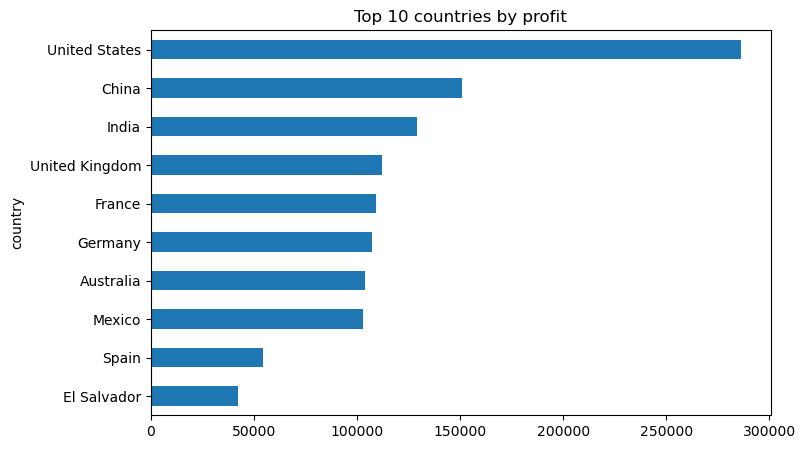

In [223]:
#top countries by profit
top_country_profit =  country_perf.sort_values(by="profit",ascending = False).head(10)
top_country_profit["profit"].sort_values().plot(kind="barh" , figsize=(8,5))
plt.title("Top 10 countries by profit")
plt.savefig('../images/Top 10 countries by profit.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# The United States leads significantly in both sales and profit, indicating its role as 
# the primary revenue and profit driver. However, some countries appear in the top sales list 
# but not in top profit, suggesting lower margins or higher operational costs in those regions. 
# This highlights a potential inefficiency where high revenue does not translate into proportional profitability. 
# The business should investigate cost structures or discounting strategies in these markets.

### 5. Which market are top contributors to sales and profit
### Horizontal Bar chart(categorical data vs numerical data)

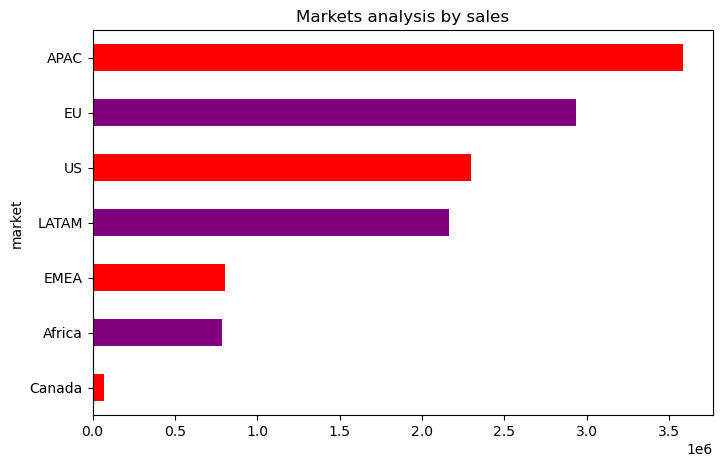

In [224]:
#aggregate
market_perf = df.groupby("market")[["sales","profit"]].sum()

#get top market by sale
top_market_sales = market_perf.sort_values(by="sales",ascending = False)
top_market_sales["sales"].sort_values().plot(kind="barh" , figsize=(8,5) , color = ["red","purple"])
plt.title("Markets analysis by sales")
plt.savefig('../images/Markets analysis by sales.png', dpi=300, bbox_inches="tight")
plt.show()

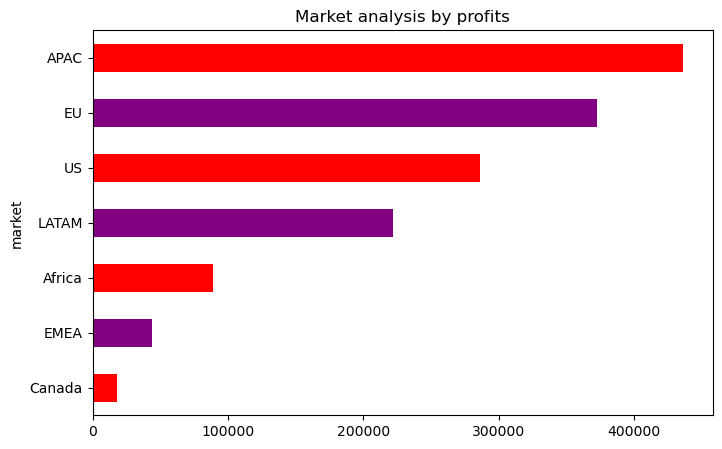

In [225]:
#top markets by profit
top_market_profit =  market_perf.sort_values(by="profit",ascending = False)
top_market_profit["profit"].sort_values().plot(kind="barh" , figsize=(8,5) , color = ["red","purple"])
plt.title("Market analysis by profits")
plt.savefig('../images/Market analysis by profits.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# The APAC,EU AND US leads significantly in both sales and profit, indicating its role as 
# the primary revenue and profit driver.

### 6. Which region are top contributors to sales and profit
### Horizontal Bar chart(categorical data vs numerical data)

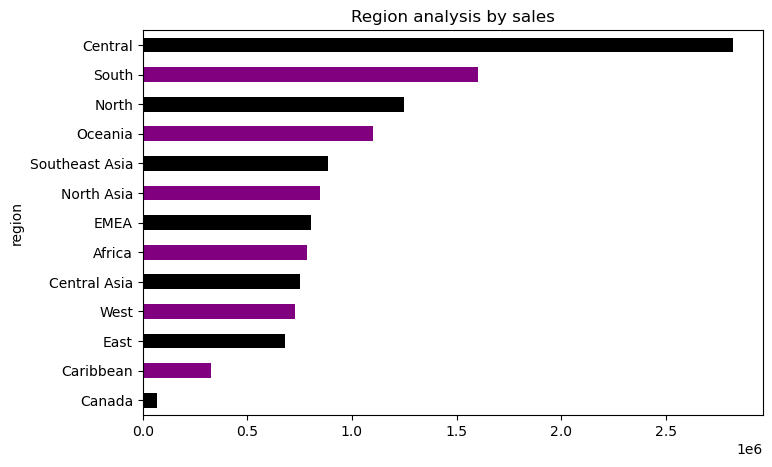

In [226]:
#aggregate
region_perf = df.groupby("region")[["sales","profit"]].sum()

#get top market by sale
top_region_sales = region_perf.sort_values(by="sales",ascending = False)
top_region_sales["sales"].sort_values().plot(kind="barh" , figsize=(8,5) , color = ["black","purple"])
plt.title("Region analysis by sales")
plt.savefig('../images/Region analysis by sales.png', dpi=300, bbox_inches="tight")
plt.show()

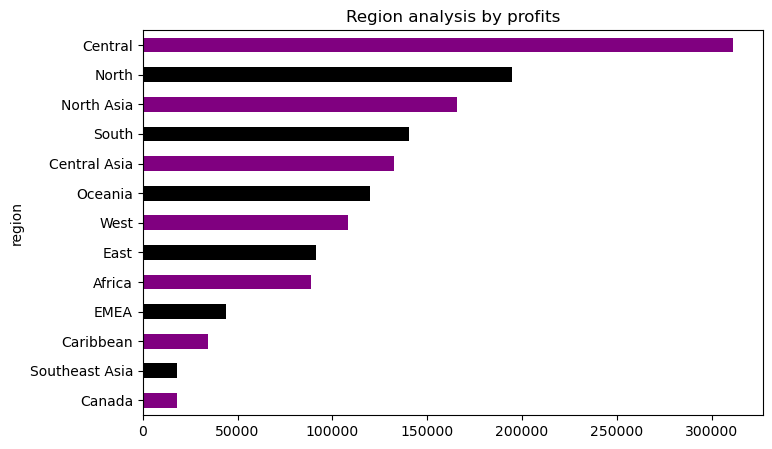

In [227]:
#top markets by profit
top_region_profit =  region_perf.sort_values(by="profit",ascending = False)
top_region_profit["profit"].sort_values().plot(kind="barh" , figsize=(8,5) , color = ["purple","black"])
plt.title("Region analysis by profits")
plt.savefig('../images/Region analysis by profits.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# The central, North AND North Asia leads significantly in both sales and profit, indicating its role as 
# the primary revenue and profit driver.

### 6. Which product categories drive order(quantity)
### Bar chart(categorical data vs numerical data)

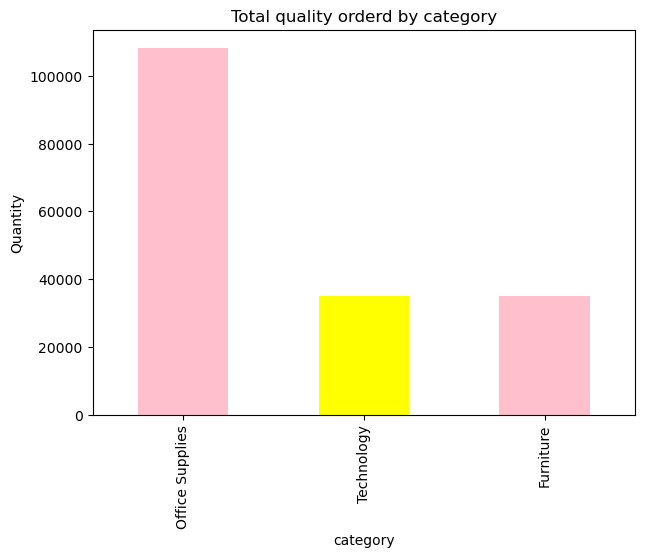

In [229]:
#aggregate
category_quan = df.groupby("category")["quantity"].sum().sort_values(ascending=False) 
#plot
category_quan.plot(kind="bar", figsize=(7,5) , color=["pink","yellow"])
plt.title("Total quality orderd by category")
plt.xlabel("category")
plt.ylabel("Quantity")
plt.savefig('../images/Total quality orderd by category.png', dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Office Supplies records the highest quantity of items ordered, indicating strong demand driven by frequent, 
# low-cost purchases. However, this does not necessarily translate to higher revenue compared to categories like Technology, 
# which may generate more sales with fewer units. This suggests a volume-driven vs value-driven dynamic across categories,
# requiring different strategic approaches for inventory and pricing.

### 7. Which categories generated more sales and profits
### Bar chart(categorical data vs numerical data)

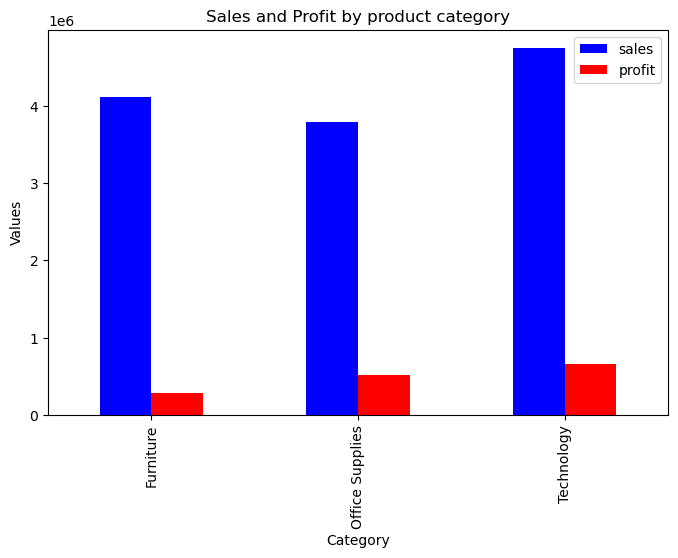

In [233]:
category_perf = df.groupby("category")[["sales","profit"]].sum()

category_perf.plot(kind="bar",figsize=(8,5) , color=["blue","red"])
plt.title("Sales and Profit by product category")
plt.xlabel("Category")
plt.ylabel("Values")
plt.savefig('../images/Sales and Profit by product category.png', dpi=300, bbox_inches="tight")
plt.show()

In [284]:
# The Technology category generates the highest sales and also leads in profitability, 
# indicating strong revenue efficiency and high-margin products. 
# In contrast, furniture shows relatively high sales but significantly lower profit,
# suggesting margin compression likely due to higher costs or discounting. This indicates that while furniture contributes to revenue, 
# it may not be as financially efficient, and cost or pricing strategies should be reviewed.

### 8. Does shipping mode affect shipping costs
### Box plots(median shipping costs, spreads and outliers)

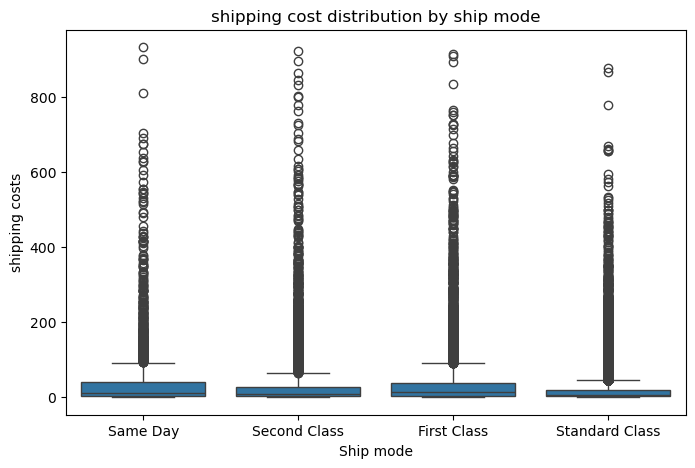

In [285]:
plt.figure(figsize=(8,5))
sns.boxplot(x="ship_mode",y="shipping_cost",data = df)
plt.title("shipping cost distribution by ship mode")
plt.xlabel("Ship mode")
plt.ylabel("shipping costs")
plt.savefig('../images/shipping cost distribution by ship mode.png', dpi=300, bbox_inches="tight")
plt.show()

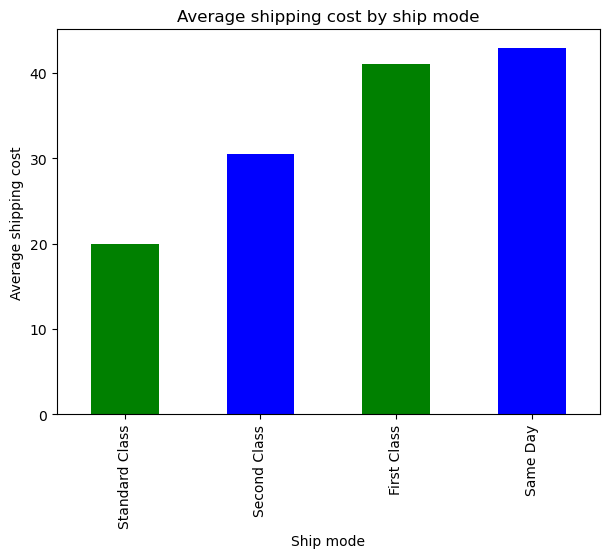

In [243]:
shipping_cost_mean = df.groupby("ship_mode")["shipping_cost"].mean().sort_values()
shipping_cost_mean.plot(kind="bar", figsize=(7,5), color=["green","blue"])
plt.title("Average shipping cost by ship mode")
plt.xlabel("Ship mode")
plt.ylabel("Average shipping cost")
plt.savefig('../images/Average shipping cost by ship mode.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Shipping cost varies significantly across ship modes, with Same Day shipping showing the highest median cost 
# and the widest distribution. Standard Class consistently has the lowest shipping cost, indicating a 
# cost-efficient delivery method. However, overlap between distributions suggests that ship mode alone does 
# not fully determine shipping cost, and other factors such as distance, weight, or logistics region likely contribute significantly.

### 9. Does order priority affect shipping costs
### Box plots(median shipping costs, spreads and outliers)

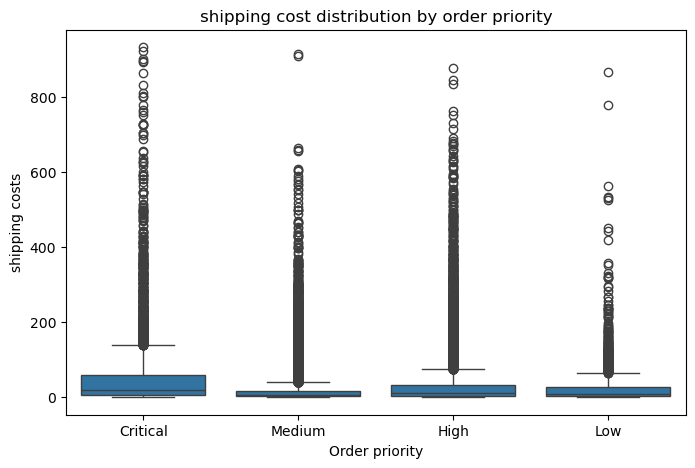

In [245]:
plt.figure(figsize=(8,5))
sns.boxplot(x="order_priority",y="shipping_cost",data = df)
plt.title("shipping cost distribution by order priority")
plt.xlabel("Order priority")
plt.ylabel("shipping costs")
plt.savefig('../images/shipping cost distribution by order priority.png', dpi=300, bbox_inches="tight")
plt.show()

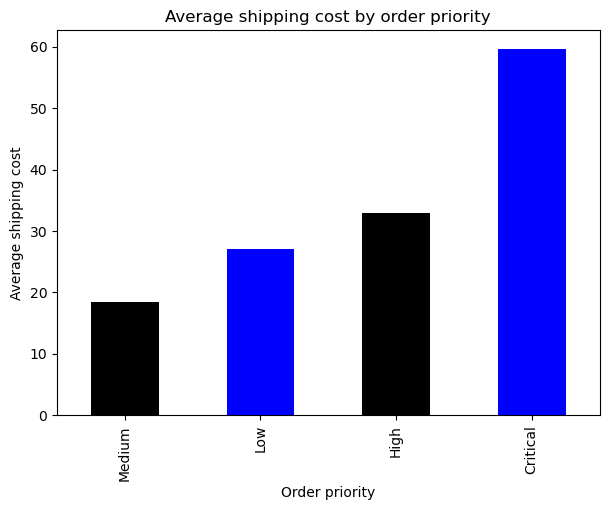

In [248]:
shipping_cost_order_mean = df.groupby("order_priority")["shipping_cost"].mean().sort_values()
shipping_cost_order_mean.plot(kind="bar", figsize=(7,5), color=["black","blue"])
plt.title("Average shipping cost by order priority")
plt.xlabel("Order priority")
plt.ylabel("Average shipping cost")
plt.savefig('../images/Average shipping cost by order priority.png', dpi=300, bbox_inches="tight")
plt.show()

In [286]:
# Shipping cost varies significantly across order priority, with critical order priority shipping showing the highest median  
# and the widest distribution. 

### 10. Which top sub categories of products contribute to sales and profits
### Grouped Bar chart

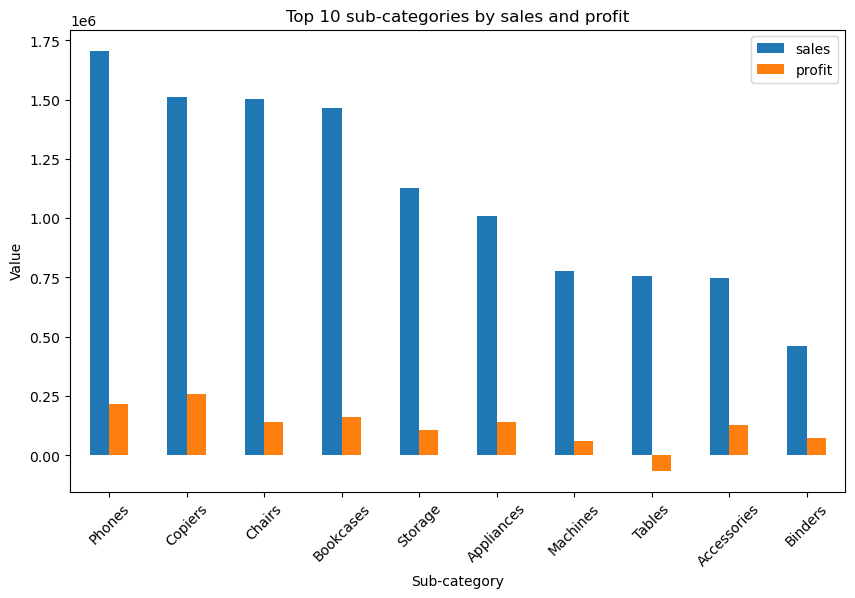

In [253]:
#aggregate data
subcat_perf = df.groupby("sub-category")[["sales","profit"]].sum()
top10 = subcat_perf.sort_values(by = "sales", ascending= False).head(10)
#plot
top10.plot(kind="bar", figsize=(10,6))
plt.title("Top 10 sub-categories by sales and profit")
plt.xlabel("Sub-category")
plt.ylabel("Value")
plt.xticks(rotation = 45)
plt.savefig('../images/Top 10 sub-categories by sales and profit.png', dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# The Phones ,Chairs and Copiers sub-categories generate the highest sales volume, indicating strong demand and revenue contribution. 
# However, Tables show relatively high sales but significantly low or negative profit, suggesting severe margin pressure, 
# likely due to discounting or high cost structures. In contrast, Copiers and Accessories demonstrate strong profit efficiency 
# relative to sales, making them more financially productive categories.

### 11. Does shipping cost differ bu ship model
### Violin plot(shows distribution shape(density), hidden clusters and multimodal behaviour)

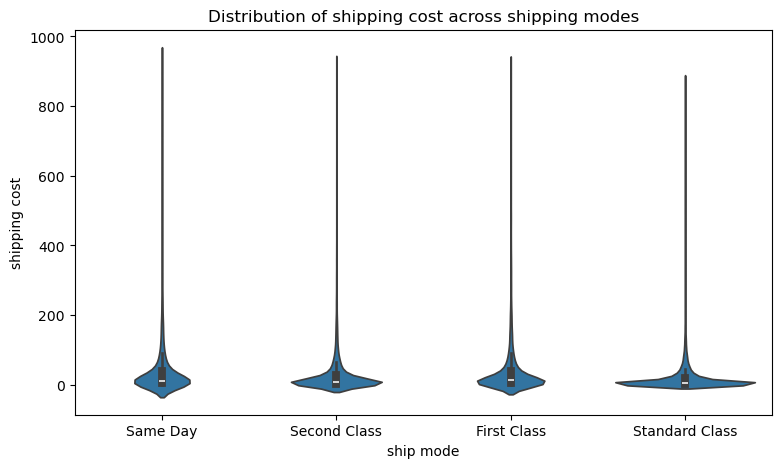

In [258]:
plt.figure(figsize=(9,5))
sns.violinplot(x="ship_mode", y ="shipping_cost" , data =df)
plt.title("Distribution of shipping cost across shipping modes")
plt.xlabel("ship mode")
plt.ylabel("shipping cost")
plt.savefig('../images/Distribution of shipping cost across shipping modest.png', dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Shipping cost distribution varies significantly across ship modes. Same Day shipping shows a wider and 
# more dispersed distribution, indicating inconsistent pricing likely influenced by distance or urgency. 
# Standard Class shows a tighter, more concentrated distribution, suggesting standardized and predictable shipping costs. The presence of multiple density peaks in faster shipping modes suggests heterogeneous cost drivers, 
# likely combining both local and long-distance deliveries.